In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

def plot_arousal_transition_counts(file_path, save_path=None):
    """
    주어진 CSV 파일에서 pre_arousal, post_arousal을 읽어
    9개 전이(L/M/H → L/M/H)별 전체 데이터 개수를 barplot으로 시각화하고
    각 막대 위에 숫자를 표시합니다.
    파일명에 있는 pXX 정보(예: p01, p15)를 추출해 제목에 반영합니다.
    """

    # 매핑
    map_num2lbl = {0: "L", 1: "M", 2: "H"}
    transitions = [
        "L→L","L→M","L→H",
        "M→L","M→M","M→H",
        "H→L","H→M","H→H"
    ]

    # 데이터 로드
    df = pd.read_csv(file_path)

    # 필수 컬럼 체크
    for col in ["pre_arousal", "post_arousal"]:
        if col not in df.columns:
            raise ValueError(f"필수 컬럼이 없습니다: {col}")

    # 숫자→라벨 변환
    df["pre_label"]  = df["pre_arousal"].map(map_num2lbl)
    df["post_label"] = df["post_arousal"].map(map_num2lbl)
    df["transition"] = df["pre_label"] + "→" + df["post_label"]

    # 전체 카운트
    counts = df["transition"].value_counts().reindex(transitions, fill_value=0)

    # 파일명에서 pXX 패턴 추출
    fname = Path(file_path).stem
    subjects = re.findall(r"p\d+", fname)
    if len(subjects) >= 2:
        title_str = f"Total Counts per Arousal Transition ({subjects[0]} → {subjects[-1]})"
    elif len(subjects) == 1:
        title_str = f"Total Counts per Arousal Transition ({subjects[0]})"
    else:
        title_str = "Total Counts per Arousal Transition"

    # Barplot
    plt.figure(figsize=(10,5))
    bars = plt.bar(counts.index, counts.values, color="skyblue", edgecolor="black")

    # 각 막대 위에 숫자 표시
    for bar, value in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value + 1,                # 막대보다 살짝 위
            str(value),
            ha="center", va="bottom",
            fontsize=9, color="black"
        )

    plt.title(title_str)
    plt.xlabel("Transition")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

    return counts


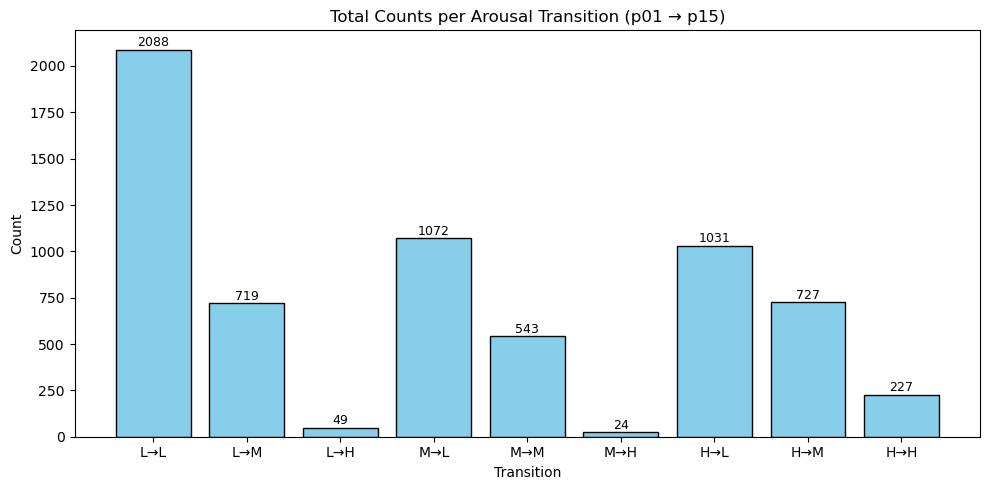

transition
L→L    2088
L→M     719
L→H      49
M→L    1072
M→M     543
M→H      24
H→L    1031
H→M     727
H→H     227
Name: count, dtype: int64


In [5]:
if __name__ == "__main__":
    # 실행할 CSV 파일 경로
    file_path = "./dataset/ml_dataset/features_p01_to_p15_arousal.csv"

    # 함수 호출
    counts = plot_arousal_transition_counts(file_path)

    print(counts)